In [57]:
pip install tensorflow xgboost lightgbm catboost scikit-learn pandas numpy

In [58]:
pip install tensorflow xgboost lightgbm catboost scikit-learn pandas numpy

In [59]:
!pip install scikeras

In [60]:
import tensorflow as tf
import scikeras

print(f"TensorFlow Version: {tf.__version__}")
print(f"Scikeras Version: {scikeras.__version__}")

TensorFlow Version: 2.19.0
Scikeras Version: 0.13.0


In [69]:
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

if TF_AVAILABLE:
    print("\n--- Cross-Validation for DNN (KerasClassifier) ---")
    try:
        # Ensure we have the input_dim for the DNN
        input_dim = X.shape[1]

        # Define a function to create the Keras model (required by KerasClassifier)
        def create_dnn_model():
            return build_deep_neural_network(input_dim)

        # Wrap the Keras model in KerasClassifier
        # We need to explicitly pass parameters like epochs, batch_size, verbose
        # Also pass callbacks if needed, but for cross_val_score, simple fitting is often preferred
        keras_model = KerasClassifier(model=create_dnn_model,
                                      epochs=50, # Use a reasonable number of epochs for CV
                                      batch_size=32,
                                      verbose=0
                                     )

        # Perform cross-validation
        # Set n_jobs=1 to avoid multiprocessing issues with Keras/TensorFlow models
        dnn_scores = cross_val_score(keras_model, X, y, cv=cv, scoring='accuracy', n_jobs=1)
        print(f"Accuracy scores: {dnn_scores}")
        print(f"Mean Accuracy: {dnn_scores.mean():.4f} (+/- {dnn_scores.std():.4f})")

    except Exception as e:
        print(f"Error during cross-validation for DNN: {e}")
else:
    print("TensorFlow is not available, skipping DNN cross-validation.")


--- Cross-Validation for DNN (KerasClassifier) ---
Error during cross-validation for DNN: 'super' object has no attribute '__sklearn_tags__'


In [62]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. ADVANCED LIBRARIES
# ============================================================

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models as keras_models # Alias 'models' to 'keras_models'
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("⚠️ TensorFlow o'rnatilmagan. pip install tensorflow")

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠️ XGBoost o'rnatilmagan. pip install xgboost")

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️ LightGBM o'rnatilmagan. pip install lightgbm")

try:
    import catboost as cb
    CB_AVAILABLE = True
except ImportError:
    CB_AVAILABLE = False
    print("⚠️ CatBoost o'rnatilmagan. pip install catboost")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split # Import train_test_split
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\n" + "="*70)
print("✅ ZAMONAVI ML/NN TIZIMI ISHGA TUSHMOQDA")
print("="*70 + "\n")

# ============================================================
# 2. ADVANCED DATA GENERATION
# ============================================================

def generate_advanced_data(n_lots=1000, n_orgs=9):
    """
    Zamonaviy va murakkab ma'lumot generatsiyasi

    Xususiyatlar:
    - Vaqt seriyasi trend
    - Seasonality (fasliy ta'siri)
    - Raqobatchi munosabatlari
    - Performance momentum
    """

    print("🔄 ADVANCED MA'LUMOT GENERATSIYASI")
    print("-" * 70)

    organizations = [f"Org_{i}" if i < n_orgs-1 else "Bizning_Org" for i in range(n_orgs)]
    # Modified: Reverse base_ratings to give 'Bizning_Org' a higher chance of winning.
    base_ratings = np.linspace(27.5, 36.2, n_orgs)

    records = []

    # Vaqt seriyasi simulyatsiyasi
    time_trend = np.sin(np.linspace(0, 4*np.pi, n_lots))  # Seasonality
    momentum = np.zeros(n_orgs)

    for lot in range(1, n_lots + 1):
        # ====== ADVANCED FEATURES ======

        # 1. Boshlang'ich ballar
        base_scores = base_ratings * 0.8 + 20

        # 2. Seasonality ta'siri
        seasonal_effect = time_trend[lot-1] * 2

        # 3. Momentum (ochko'ki g'alaba/mag'lubiyat davomiyligi)
        momentum += np.random.normal(0, 0.5, n_orgs)
        momentum = np.clip(momentum, -5, 5)

        # 4. Raqobatchi va'z-nasihati (correlation)
        competition_effect = np.random.normal(0, 1, n_orgs)

        # 5. Xavfning o'zgaruvchanligi (volatility)
        volatility = np.random.uniform(0.05, 0.15, n_orgs)

        # Final scores bilan hamma ta'sirlarni birlashtirish
        final_scores = (
            base_scores +
            seasonal_effect +
            momentum * 0.3 +
            competition_effect * 0.5 +
            np.random.normal(0, volatility)
        )

        # G'alob aniqlanadi
        winner_idx = np.argmax(final_scores)
        winner = organizations[winner_idx]

        # ====== FEATURE ENGINEERING ======
        lot_record = {'Lot': lot, 'Winner': winner}

        # Har bir organizatsiya uchun features
        for i, org in enumerate(organizations):
            lot_record[f'Score_{org}'] = final_scores[i]
            lot_record[f'Win_{org}'] = 1 if i == winner_idx else 0
            lot_record[f'Momentum_{org}'] = momentum[i]
            lot_record[f'Volatility_{org}'] = volatility[i]

        # Global features
        lot_record['Time_Trend'] = seasonal_effect
        lot_record['Avg_Score'] = np.mean(final_scores)
        lot_record['Score_Std'] = np.std(final_scores)
        lot_record['Score_Range'] = np.max(final_scores) - np.min(final_scores)
        lot_record['Max_Score'] = np.max(final_scores)
        lot_record['Min_Score'] = np.min(final_scores)

        records.append(lot_record)

        if (lot + 1) % 200 == 0:
            print(f"   ✓ {lot} ta lot yaratildi...")

    df = pd.DataFrame(records)
    print(f"   ✅ Yakunlandi: {len(df)} ta lot\n")

    return df, organizations


# ============================================================
# 3. DEEP NEURAL NETWORK
# ============================================================

def build_deep_neural_network(input_dim, learning_rate=0.001, compile_model=True):
    """
    Zamonaviy Deep Neural Network (DNN)

    Arxitektura:
    Input → BatchNorm → Dense(256) → ReLU → Dropout(0.3) →
            Dense(128) → ReLU → Dropout(0.3) →
            Dense(64) → ReLU → Dropout(0.2) →
            Dense(32) → ReLU → Dropout(0.2) →
            Dense(1) → Sigmoid → Output
    """

    if not TF_AVAILABLE:
        print("⚠️ TensorFlow o'rnatilmagan!")
        return None

    model = keras_models.Sequential([ # Use aliased name 'keras_models'
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),

        # Layer 1
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),

        # Layer 2
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.3),

        # Layer 3
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.2),

        # Layer 4
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dropout(0.2),

        # Output
        layers.Dense(1, activation='sigmoid')
    ])

    if compile_model:
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )

    return model


# ============================================================
# 4. LSTM NETWORK (VAQT SERIYASI UCHUN)
# ============================================================

def build_lstm_network(input_shape, learning_rate=0.001):
    """
    LSTM (Long Short-Term Memory) Network
    Vaqt seriyasi dependencies uchun ideal

    Arxitektura:
    Input → LSTM(128) → LSTM(64) → Dense(32) → Dense(1) → Sigmoid
    """

    if not TF_AVAILABLE:
        return None

    model = keras_models.Sequential([ # Use aliased name 'keras_models'
        layers.Input(shape=input_shape),

        # LSTM layers
        layers.LSTM(128, return_sequences=True, dropout=0.2),
        layers.LSTM(64, return_sequences=False, dropout=0.2),

        # Dense layers
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    return model


# ============================================================
# 5. XGBOOST - SUPREME GRADIENT BOOSTING
# ============================================================

def build_xgboost_model():
    """
    XGBoost - Eng kuchli Gradient Boosting

    Xususiyatlar:
    - Parallel processing
    - GPU support
    - Regularization
    - Missing values handling
    """

    if not XGB_AVAILABLE:
        return None

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=0.5,      # L1 regularization
        reg_lambda=1,       # L2 regularization
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss',
        tree_method='hist'
    )

    return model


# ============================================================
# 6. LIGHTGBM - TEZKOR VA SAMARALI
# ============================================================

def build_lightgbm_model():
    """
    LightGBM - Tezkor Gradient Boosting

    Xususiyatlar:
    - Parallel va GPU learning
    - Kichik memory footprint
    - Category features
    """

    if not LGBM_AVAILABLE:
        return None

    model = lgb.LGBMClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        num_leaves=31,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        verbosity=-1
    )

    return model


# ============================================================
# 7. CATBOOST - CATEGORY BOOSTING
# ============================================================

def build_catboost_model(enable_use_best_model=True):
    """
    CatBoost - Imbalans va kategoriya ma'lumotlar uchun

    Xususiyatlar:
    - Automatic feature interaction
    - Best for categorical features
    - Class weight support
    """

    if not CB_AVAILABLE:
        return None

    model = cb.CatBoostClassifier(
        iterations=400,
        depth=5,
        learning_rate=0.08,
        subsample=0.8,
        scale_pos_weight=2,  # Imbalans uchun weight
        random_state=42,
        verbose=0,
        use_best_model=enable_use_best_model
    )

    return model


# ============================================================
# 8. ENSEMBLE & STACKING
# ============================================================

def build_ensemble_model(X_train, y_train, X_val, y_val):
    """
    Ensemble Learning - Ko'plab modellarni birlashtirish

    Strategy:
    1. Base Learners: XGBoost, LightGBM, CatBoost, DNN
    2. Meta Learner: Logistic Regression
    """

    print("\n🏗️  ENSEMBLE MODEL QURILMOQDA...")
    print("-" * 70)

    base_learners = []

    # XGBoost
    if XGB_AVAILABLE:
        xgb_model = build_xgboost_model()
        xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)
        base_learners.append(('xgboost', xgb_model))
        print("   ✓ XGBoost base learner tayyorlandi")

    # LightGBM
    if LGBM_AVAILABLE:
        lgbm_model = build_lightgbm_model()
        lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)]) # Removed verbose=0
        base_learners.append(('lightgbm', lgbm_model))
        print("   ✓ LightGBM base learner tayyorlandi")

    # CatBoost
    if CB_AVAILABLE:
        cb_model = build_catboost_model(enable_use_best_model=False) # Modified: Disable use_best_model for ensemble base learner
        cb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)
        base_learners.append(('catboost', cb_model))
        print("   ✓ CatBoost base learner tayyorlandi")

    if len(base_learners) == 0:
        print("⚠️ Hech qanday Boosting library o'rnatilmagan!")
        return None

    # Ensemble voting classifier
    ensemble = VotingClassifier(
        estimators=base_learners,
        voting='soft'  # Probability-based
    )

    ensemble.fit(X_train, y_train)
    print("   ✓ Ensemble Model tayyorlandi\n")

    return ensemble


# ============================================================
# 9. MODEL TRAINING & EVALUATION
# ============================================================

def train_all_models(X_train, X_test, y_train, y_test, X_val=None, y_val=None):
    """
    Barcha advanced modellarni o'qitish
    """

    # Validation set
    if X_val is None:
        # Modified: Use stratified split for validation set
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

    results = {}

    print("\n" + "="*70)
    print("🤖 ADVANCED MODELLARNI O'QITISH")
    print("="*70 + "\n")

    # ====== 1. DEEP NEURAL NETWORK ======
    if TF_AVAILABLE:
        print("1️⃣ DEEP NEURAL NETWORK o'qitilmoqda...")
        print("-" * 70)

        dnn = build_deep_neural_network(X_train.shape[1])

        early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

        history_dnn = dnn.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=200,
            batch_size=32,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        y_pred_dnn = (dnn.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

        results['DNN'] = {
            'model': dnn,
            'predictions': y_pred_dnn,
            'history': history_dnn,
            'accuracy': accuracy_score(y_test, y_pred_dnn),
            'auc': roc_auc_score(y_test, dnn.predict(X_test, verbose=0))
        }

        print(f"   ✓ Accuracy: {results['DNN']['accuracy']:.4f}")
        print(f"   ✓ AUC-ROC: {results['DNN']['auc']:.4f}\n")

    # ====== 2. XGBOOST ======
    if XGB_AVAILABLE:
        print("2️⃣ XGBOOST o'qitilmoqda...")
        print("-" * 70)

        xgb_model = build_xgboost_model()
        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=0
        )

        y_pred_xgb = xgb_model.predict(X_test)

        results['XGBoost'] = {
            'model': xgb_model,
            'predictions': y_pred_xgb,
            'accuracy': accuracy_score(y_test, y_pred_xgb),
            'auc': roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
        }

        print(f"   ✓ Accuracy: {results['XGBoost']['accuracy']:.4f}")
        print(f"   ✓ AUC-ROC: {results['XGBoost']['auc']:.4f}\n")

    # ====== 3. LIGHTGBM ======
    if LGBM_AVAILABLE:
        print("3️⃣ LIGHTGBM o'qitilmoqda...")
        print("-" * 70)

        lgbm_model = build_lightgbm_model()
        lgbm_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)]
            # Removed verbose=0
        )

        y_pred_lgbm = lgbm_model.predict(X_test)

        results['LightGBM'] = {
            'model': lgbm_model,
            'predictions': y_pred_lgbm,
            'accuracy': accuracy_score(y_test, y_pred_lgbm),
            'auc': roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:, 1])
        }

        print(f"   ✓ Accuracy: {results['LightGBM']['accuracy']:.4f}")
        print(f"   ✓ AUC-ROC: {results['LightGBM']['auc']:.4f}\n")

    # ====== 4. CATBOOST ======
    if CB_AVAILABLE:
        print("4️⃣ CATBOOST o'qitilmoqda...")
        print("-" * 70)

        cb_model = build_catboost_model(enable_use_best_model=True) # Ensure it's True for individual training
        cb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=0
        )

        y_pred_cb = cb_model.predict(X_test)

        results['CatBoost'] = {
            'model': cb_model,
            'predictions': y_pred_cb,
            'accuracy': accuracy_score(y_test, y_pred_cb),
            'auc': roc_auc_score(y_test, cb_model.predict_proba(X_test)[:, 1])
        }

        print(f"   ✓ Accuracy: {results['CatBoost']['accuracy']:.4f}")
        print(f"   ✓ AUC-ROC: {results['CatBoost']['auc']:.4f}\n")

    # ====== 5. ENSEMBLE ======
    ensemble = build_ensemble_model(X_train, y_train, X_val, y_val)
    if ensemble:
        y_pred_ensemble = ensemble.predict(X_test)

        results['Ensemble'] = {
            'model': ensemble,
            'predictions': y_pred_ensemble,
            'accuracy': accuracy_score(y_test, y_pred_ensemble),
            'auc': roc_auc_score(y_test, ensemble.predict_proba(X_test)[:, 1])
        }

        print(f"   ✓ Accuracy: {results['Ensemble']['accuracy']:.4f}")
        print(f"   ✓ AUC-ROC: {results['Ensemble']['auc']:.4f}\n")

    return results


# ============================================================
# 10. MODEL COMPARISON & ANALYSIS
# ============================================================

def display_model_comparison(results, y_test):
    """
    Barcha modellarni taqqoslash
    """

    print("\n" + "="*70)
    print("📊 MODEL TAQQOSLASH")
    print("="*70 + "\n")

    comparison_data = []

    for model_name, model_data in results.items():
        y_pred = model_data['predictions']

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = model_data.get('auc', 0)

        comparison_data.append({
            'Model': model_name,
            'Accuracy': f"{accuracy:.4f}",
            'Precision': f"{precision:.4f}",
            'Recall': f"{recall:.4f}",
            'F1-Score': f"{f1:.4f}",
            'AUC-ROC': f"{auc:.4f}"
        })

    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))
    print()

    return df_comparison


def display_detailed_metrics(results, y_test):
    """
    Detailed metrics va confusion matrix
    """

    print("\n" + "="*70)
    print("🔍 BATAFSIL METRIKALARI")
    print("="*70 + "\n")

    for model_name, model_data in results.items():
        y_pred = model_data['predictions']

        print(f"\n{'='*70}")
        print(f"📌 {model_name}")
        print(f"{'='*70}")
        print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
        print("Classification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))


def display_feature_importance(results):
    """
    Feature importance uchun tree-based models
    """

    print("\n" + "="*70)
    print("📈 FEATURE IMPORTANCE")
    print("="*70 + "\n")

    for model_name, model_data in results.items():
        model = model_data['model']

        # XGBoost, LightGBM, CatBoost uchun
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[-10:]  # Top 10

            print(f"\n{model_name} - Top 10 Muhim Features:")
            for idx in reversed(indices):
                print(f"   {idx}: {importances[idx]:.4f}")


# ============================================================
# 11. MAIN PROGRAM
# ============================================================

def main():
    """
    Asosiy dastur
    """

    print("\n" + "="*70)
    print("🚀 ADVANCED RAQOBAT TAXMIN TIZIMI")
    print("="*70)

    # 1. Data generation
    print("\n1️⃣ ADVANCED MA'LUMOT GENERATSIYASI")
    df_data, organizations = generate_advanced_data(n_lots=1000, n_orgs=9)

    # 2. Feature preparation
    print("\n2️⃣ FEATURE TAYYORLASH")
    print("-" * 70)

    feature_cols = [col for col in df_data.columns
                   if col not in ['Lot', 'Winner']]
    X = df_data[feature_cols].values
    y = (df_data['Winner'] == 'Bizning_Org').astype(int).values

    print(f"   ✓ Features: {len(feature_cols)}")
    print(f"   ✓ Samples: {len(X)}")
    print(f"   ✓ Target balans: {y.sum()}/{len(y)} ({y.mean()*100:.1f}%)\n")

    # Normalization
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/Test split (Modified: Use stratified split)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

    print(f"   ✓ O'qitish: {len(X_train)}")
    print(f"   ✓ Test: {len(X_test)}\n")

    # 3. Train all models
    results = train_all_models(X_train, X_test, y_train, y_test)

    # 4. Display results
    display_model_comparison(results, y_test)
    display_detailed_metrics(results, y_test)
    display_feature_importance(results)

    # 5. Best model
    print("\n" + "="*70)
    print("🏆 ENG YAXSHI MODEL")
    print("="*70 + "\n")

    best_model_name = max(results.keys(),
                         key=lambda k: results[k]['accuracy'])
    best_accuracy = results[best_model_name]['accuracy']
    best_auc = results[best_model_name]['auc']

    print(f"✨ {best_model_name}")
    print(f"   Accuracy: {best_accuracy:.4f}")
    print(f"   AUC-ROC: {best_auc:.4f}")

    # 6. Predictions
    print("\n" + "="*70)
    print("🎯 SO'NGGI 10 LOTKADA BASHORAT")
    print("="*70 + "\n")

    best_model = results[best_model_name]['model']
    last_10_preds = best_model.predict(X_test[-10:])

    for i, pred in enumerate(last_10_preds):
        actual = y_test[-(10-i)]
        status = "✅ To'g'ri" if pred == actual else "❌ Xato"
        result = "G'aloba" if pred == 1 else "Mag'lubiyat"
        print(f"Lot {len(df_data)-9+i}: {result:12s} - {status}")

    print("\n" + "="*70)
    print("✅ DASTUR YAKUNLANDI")
    print("="*70 + "\n")

    return df_data, results, X_scaled, y


# ============================================================
# 12. EXECUTE
# ============================================================

if __name__ == "__main__":
    try:
        df_simulation, models, X_features, y_target = main()
        print("\n💾 Modellar memory'da saqlandi\n")
    except Exception as e:
        print(f"\n❌ Xato: {e}")
        print("\n📦 Kerakli kutubxonalar o'rnatish:")
        print("   pip install tensorflow xgboost lightgbm catboost scikit-learn pandas numpy")



✅ ZAMONAVI ML/NN TIZIMI ISHGA TUSHMOQDA


🚀 ADVANCED RAQOBAT TAXMIN TIZIMI

1️⃣ ADVANCED MA'LUMOT GENERATSIYASI
🔄 ADVANCED MA'LUMOT GENERATSIYASI
----------------------------------------------------------------------
   ✓ 199 ta lot yaratildi...
   ✓ 399 ta lot yaratildi...
   ✓ 599 ta lot yaratildi...
   ✓ 799 ta lot yaratildi...
   ✓ 999 ta lot yaratildi...
   ✅ Yakunlandi: 1000 ta lot


2️⃣ FEATURE TAYYORLASH
----------------------------------------------------------------------
   ✓ Features: 42
   ✓ Samples: 1000
   ✓ Target balans: 399/1000 (39.9%)

   ✓ O'qitish: 800
   ✓ Test: 200


🤖 ADVANCED MODELLARNI O'QITISH

1️⃣ DEEP NEURAL NETWORK o'qitilmoqda...
----------------------------------------------------------------------
   ✓ Accuracy: 1.0000
   ✓ AUC-ROC: 1.0000

2️⃣ XGBOOST o'qitilmoqda...
----------------------------------------------------------------------
   ✓ Accuracy: 1.0000
   ✓ AUC-ROC: 1.0000

3️⃣ LIGHTGBM o'qitilmoqda...
------------------------------------------

In [70]:
"""
Raqobat Taxmin Modeli
Competition Prediction Model with Machine Learning
===============================================
Bu skript tashkilotlar orasidagi raqobat natijalarini bashorat qiladi.
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. TASHKILOT MA'LUMOTLARI VA BOSHLANG'ICH SOZLAMALAR
# ============================================================

def setup_organizations():
    """Tashkilotlar ro'yxatini va ularning boshlang'ich ballarini o'rnatish"""
    organizations = [
        "Tashkilot 1", "Tashkilot 2", "Tashkilot 3",
        "Tashkilot 4", "Tashkilot 5", "Tashkilot 6",
        "Tashkilot 7", "Tashkilot 8", "Bizning tashkilot"
    ]

    ratings = [36.2, 35.5, 34.7, 33.1, 32.5, 31.0, 30.5, 29.8, 27.5]
    initial_scores = [r * 0.8 + 20 for r in ratings]
    penalties = [r * 0.04 for r in ratings]

    df_setup = pd.DataFrame({
        'Tashkilot': organizations,
        'Reyting_bal': ratings,
        'Boshlangich_ball': initial_scores,
        'Jarima': penalties
    })

    return df_setup, organizations


# ============================================================
# 2. SIMULYATSIYA MA'LUMOTLARINI GENERATSIYA QILISH
# ============================================================

def generate_simulation_data(setup_df, n_lots=500):
    """
    Raqobat lotlari uchun ma'lumotlarni generatsiya qilish

    Parameters:
    -----------
    setup_df : DataFrame
        Tashkilotlar ma'lumotlari
    n_lots : int
        Yaratilishi kerak bo'lgan lot soni

    Returns:
    --------
    DataFrame : Simulyatsiya natijalarini o'z ichiga olgan DataFrame
    """
    organizations = setup_df['Tashkilot'].tolist()
    n = len(organizations)

    initial_scores = setup_df['Boshlangich_ball'].values.copy()
    penalties = setup_df['Jarima'].values.copy()
    current_scores = initial_scores.copy()
    wins = np.zeros(n, dtype=int)

    records = []

    print(f"📊 {n_lots} ta lot uchun ma'lumot generatsiya qilinmoqda...")

    for lot in range(1, n_lots + 1):
        # Tasodifiy shovqin qo'shish (realistik bo'lishi uchun)
        noise = np.random.normal(0, 0.1, n)
        scores_with_noise = current_scores + noise

        # G'olib aniqlanadi (eng yuqori ball bilan)
        max_score = np.max(scores_with_noise)
        winner_idx = np.where(scores_with_noise == max_score)[0][0]
        winner_name = organizations[winner_idx]

        # Lot natijasini saqlash
        lot_record = {
            'Lot': lot,
            'Gholib': winner_name,
            'Gholib_ball': round(max_score, 4)
        }

        # Har bir tashkilot uchun ball va g'alaba/mag'lubiyatni saqlash
        for i, org in enumerate(organizations):
            lot_record[f'Ball_{org}'] = round(current_scores[i], 4)
            lot_record[f'Win_{org}'] = 1 if i == winner_idx else 0

        wins[winner_idx] += 1
        records.append(lot_record)

        # Ballarni yangilash (Jarima mexanizmi)
        for i in range(n):
            current_scores[i] = initial_scores[i] - (wins[i] * penalties[i])
            if current_scores[i] < 0:
                current_scores[i] = 0

        # Taraqqiyot ko'rsatish
        if (lot + 1) % 100 == 0:
            print(f"   ✓ {lot + 1} ta lot yaratildi...")

    return pd.DataFrame(records)


# ============================================================
# 3. MA'LUMOTLARNI O'QITISH VA TAYYORLASH
# ============================================================

def prepare_data(df_sim, organizations, test_size=0.2):
    """
    Ma'lumotlarni o'qitish va test to'plamlariga bo'lish

    Parameters:
    -----------
    df_sim : DataFrame
        Simulyatsiya ma'lumotlari
    organizations : list
        Tashkilotlar nomi
    test_size : float
        Test to'plamining hajmi

    Returns:
    --------
    tuple : (X_train, X_test, y_train, y_test)
    """
    # Feature'larni (xususiyatlarni) tanlash
    ball_columns = [f'Ball_{org}' for org in organizations]
    X_data = df_sim[ball_columns].values

    # Target'ni belgilash (Bizning tashkilot g'alaba qildi)
    y_data = (df_sim['Gholib'] == 'Bizning tashkilot').astype(int).values

    # O'qitish va test to'plamlariga bo'lish
    split_idx = int(len(X_data) * (1 - test_size))
    X_train, X_test = X_data[:split_idx], X_data[split_idx:]
    y_train, y_test = y_data[:split_idx], y_data[split_idx:]

    # Ma'lumotlarni normalizatsiya qilish
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


# ============================================================
# 4. MODELNI O'QITISH VA BAHOLASH
# ============================================================

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """
    Bir necha ML modelni o'qitish va baholash

    Parameters:
    -----------
    X_train, X_test : array
        O'qitish va test ma'lumotlari
    y_train, y_test : array
        O'qitish va test target'lari

    Returns:
    --------
    dict : O'qitilgan modellar va ularning natijalarini o'z ichiga olgan dictionary
    """
    models = {
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            random_state=42,
            learning_rate=0.1
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=150,
            max_depth=8,
            random_state=42
        ),
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    }

    results = {}

    print("\n" + "="*60)
    print("🤖 MODELLARNI O'QITISH VA BAHOLASH")
    print("="*60)

    for name, model in models.items():
        # Modelni o'qitish
        print(f"\n📚 {name} o'qitilmoqda...")
        model.fit(X_train, y_train)

        # Taxminlar
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Metrikalari hisoblash
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)
        precision = precision_score(y_test, y_pred_test, zero_division=0)
        recall = recall_score(y_test, y_pred_test, zero_division=0)
        f1 = f1_score(y_test, y_pred_test, zero_division=0)

        results[name] = {
            'model': model,
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred_test
        }

        # Natijalarni chiqarish
        print(f"   ✓ O'qitish aniqligi: {train_acc:.2%}")
        print(f"   ✓ Test aniqligi: {test_acc:.2%}")
        print(f"   ✓ Precision: {precision:.2%}")
        print(f"   ✓ Recall: {recall:.2%}")
        print(f"   ✓ F1-Score: {f1:.2%}")

    return results


# ============================================================
# 5. NATIJALARNI TAHLIL QILISH VA KO'RSATISH
# ============================================================

def display_predictions(df_sim, results, n_recent=10):
    """
    So'nggi lotlar uchun taxminlarni ko'rsatish

    Parameters:
    -----------
    df_sim : DataFrame
        Simulyatsiya ma'lumotlari
    results : dict
        Modellarning natijalari
    n_recent : int
        Ko'rsatish kerak bo'lgan so'nggi lot soni
    """
    print("\n" + "="*60)
    print("🏆 SO'NGGI LOTLARDAGI BIZNING TASHKILOTNING TAXMINLARI")
    print("="*60)

    best_model_name = max(results.keys(),
                          key=lambda k: results[k]['test_accuracy'])
    best_model = results[best_model_name]['model']

    print(f"\n✨ Eng yaxshi model: {best_model_name}")
    print(f"   Aniqligi: {results[best_model_name]['test_accuracy']:.2%}\n")

    # So'nggi n_recent lot uchun
    start_idx = max(0, len(df_sim) - n_recent)
    for idx in range(start_idx, len(df_sim)):
        lot_num = df_sim.iloc[idx]['Lot']
        actual_winner = df_sim.iloc[idx]['Gholib']

        # Agar haqiqiy g'alaba Bizning tashkilot bo'lsa
        actual_result = 1 if actual_winner == 'Bizning tashkilot' else 0

        print(f"Lot #{int(lot_num)}:")
        print(f"   Haqiqiy natija: {'✅ G\'alaba' if actual_result == 1 else '❌ Mag\'lubiyat'} ({actual_winner})")
        print()


def display_statistics(df_sim, organizations):
    """
    Simulyatsiya statistikasini ko'rsatish

    Parameters:
    -----------
    df_sim : DataFrame
        Simulyatsiya ma'lumotlari
    organizations : list
        Tashkilotlar nomi
    """
    print("\n" + "="*60)
    print("📈 RAQOBAT STATISTIKASI")
    print("="*60 + "\n")

    for org in organizations:
        wins = (df_sim['Gholib'] == org).sum()
        total = len(df_sim)
        percentage = (wins / total) * 100

        bar_length = int(percentage / 2)
        bar = "█" * bar_length + "░" * (50 - bar_length)

        print(f"{org:20} | {bar} | {wins:3d}/{total} ({percentage:5.1f}%)")


# ============================================================
# 6. ASOSIY DASTUR MANTIG'I
# ============================================================

def main():
    """Asosiy dastur"""

    print("\n" + "="*60)
    print("🚀 RAQOBAT TAXMIN TIZIMI ISHGA TUSHMOQDA")
    print("="*60)

    # 1. Tashkilotlarni o'rnatish
    print("\n1️⃣ Tashkilotlar ma'lumotlari o'rnatilmoqda...")
    df_setup, organizations = setup_organizations()
    print(f"   ✓ {len(organizations)} ta tashkilot tayyorlandi")
    print(df_setup.to_string(index=False))

    # 2. Simulyatsiya ma'lumotlarini generatsiya qilish
    print("\n2️⃣ Simulyatsiya ma'lumotlarini generatsiya qilish...")
    df_sim = generate_simulation_data(df_setup, n_lots=500)
    print(f"   ✅ Yakunlandi: {len(df_sim)} ta lot ma'lumotlari yaratildi\n")

    # 3. Ma'lumotlarni tayyorlash
    print("3️⃣ Ma'lumotlarni o'qitish va test to'plamlariga bo'lish...")
    X_train, X_test, y_train, y_test, scaler = prepare_data(df_sim, organizations)
    print(f"   ✓ O'qitish to'plami: {len(X_train)} namuna")
    print(f"   ✓ Test to'plami: {len(X_test)} namuna\n")

    # 4. Modellarni o'qitish
    print("4️⃣ ML modellarni o'qitish...")
    results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

    # 5. Natijalarni ko'rsatish
    print("\n5️⃣ Natijalarni ko'rsatish...")
    display_predictions(df_sim, results, n_recent=10)

    # 6. Statistikani ko'rsatish
    display_statistics(df_sim, organizations)

    print("\n" + "="*60)
    print("✅ DASTUR YAKUNLANDI")
    print("="*60 + "\n")

    return df_sim, df_setup, results, scaler


# ============================================================
# 7. DASTURNI ISHGA TUSHIRISH
# ============================================================

if __name__ == "__main__":
    df_simulation, df_setup_data, model_results, data_scaler = main()

    # Kerak bo'lsa, ma'lumotlarni saqlay olasiz:
    # df_simulation.to_csv('simulyatsiya_natijalari.csv', index=False)
    # print("\n💾 Ma'lumotlar 'simulyatsiya_natijalari.csv' ga saqlandi")


🚀 RAQOBAT TAXMIN TIZIMI ISHGA TUSHMOQDA

1️⃣ Tashkilotlar ma'lumotlari o'rnatilmoqda...
   ✓ 9 ta tashkilot tayyorlandi
        Tashkilot  Reyting_bal  Boshlangich_ball  Jarima
      Tashkilot 1         36.2             48.96   1.448
      Tashkilot 2         35.5             48.40   1.420
      Tashkilot 3         34.7             47.76   1.388
      Tashkilot 4         33.1             46.48   1.324
      Tashkilot 5         32.5             46.00   1.300
      Tashkilot 6         31.0             44.80   1.240
      Tashkilot 7         30.5             44.40   1.220
      Tashkilot 8         29.8             43.84   1.192
Bizning tashkilot         27.5             42.00   1.100

2️⃣ Simulyatsiya ma'lumotlarini generatsiya qilish...
📊 500 ta lot uchun ma'lumot generatsiya qilinmoqda...
   ✓ 100 ta lot yaratildi...
   ✓ 200 ta lot yaratildi...
   ✓ 300 ta lot yaratildi...
   ✓ 400 ta lot yaratildi...
   ✓ 500 ta lot yaratildi...
   ✅ Yakunlandi: 500 ta lot ma'lumotlari yaratildi

3️⃣

In [71]:
display_feature_importance(models)


📈 FEATURE IMPORTANCE


XGBoost - Top 10 Muhim Features:
   33: 0.3174
   29: 0.2349
   25: 0.1604
   26: 0.1272
   21: 0.0642
   34: 0.0215
   32: 0.0199
   38: 0.0174
   18: 0.0133
   24: 0.0132

LightGBM - Top 10 Muhim Features:
   33: 345.0000
   29: 13.0000
   26: 6.0000
   25: 6.0000
   20: 3.0000
   32: 3.0000
   34: 1.0000
   21: 1.0000
   40: 0.0000
   41: 0.0000

CatBoost - Top 10 Muhim Features:
   33: 92.7584
   3: 0.4628
   27: 0.4568
   4: 0.4334
   11: 0.4236
   32: 0.4143
   19: 0.4053
   14: 0.3019
   15: 0.2853
   35: 0.2806


In [65]:
from sklearn.model_selection import train_test_split

# Re-create y_test as it's not directly returned by main()
# X_features and y_target are the X_scaled and y from main() respectively.
_, _, _, y_test_correct = train_test_split(X_features, y_target, test_size=0.2, stratify=y_target, random_state=42)

display_model_comparison(models, y_test_correct)


📊 MODEL TAQQOSLASH

   Model Accuracy Precision Recall F1-Score AUC-ROC
     DNN   1.0000    1.0000 1.0000   1.0000  1.0000
 XGBoost   1.0000    1.0000 1.0000   1.0000  1.0000
LightGBM   1.0000    1.0000 1.0000   1.0000  1.0000
CatBoost   1.0000    1.0000 1.0000   1.0000  1.0000
Ensemble   1.0000    1.0000 1.0000   1.0000  1.0000



,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,DNN,1.0000,1.0000,1.0000,1.0000,1.0000
1,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
2,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000
3,CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000
4,Ensemble,1.0000,1.0000,1.0000,1.0000,1.0000



📊 PROBABILITY PREDICTION DISTRIBUTIONS



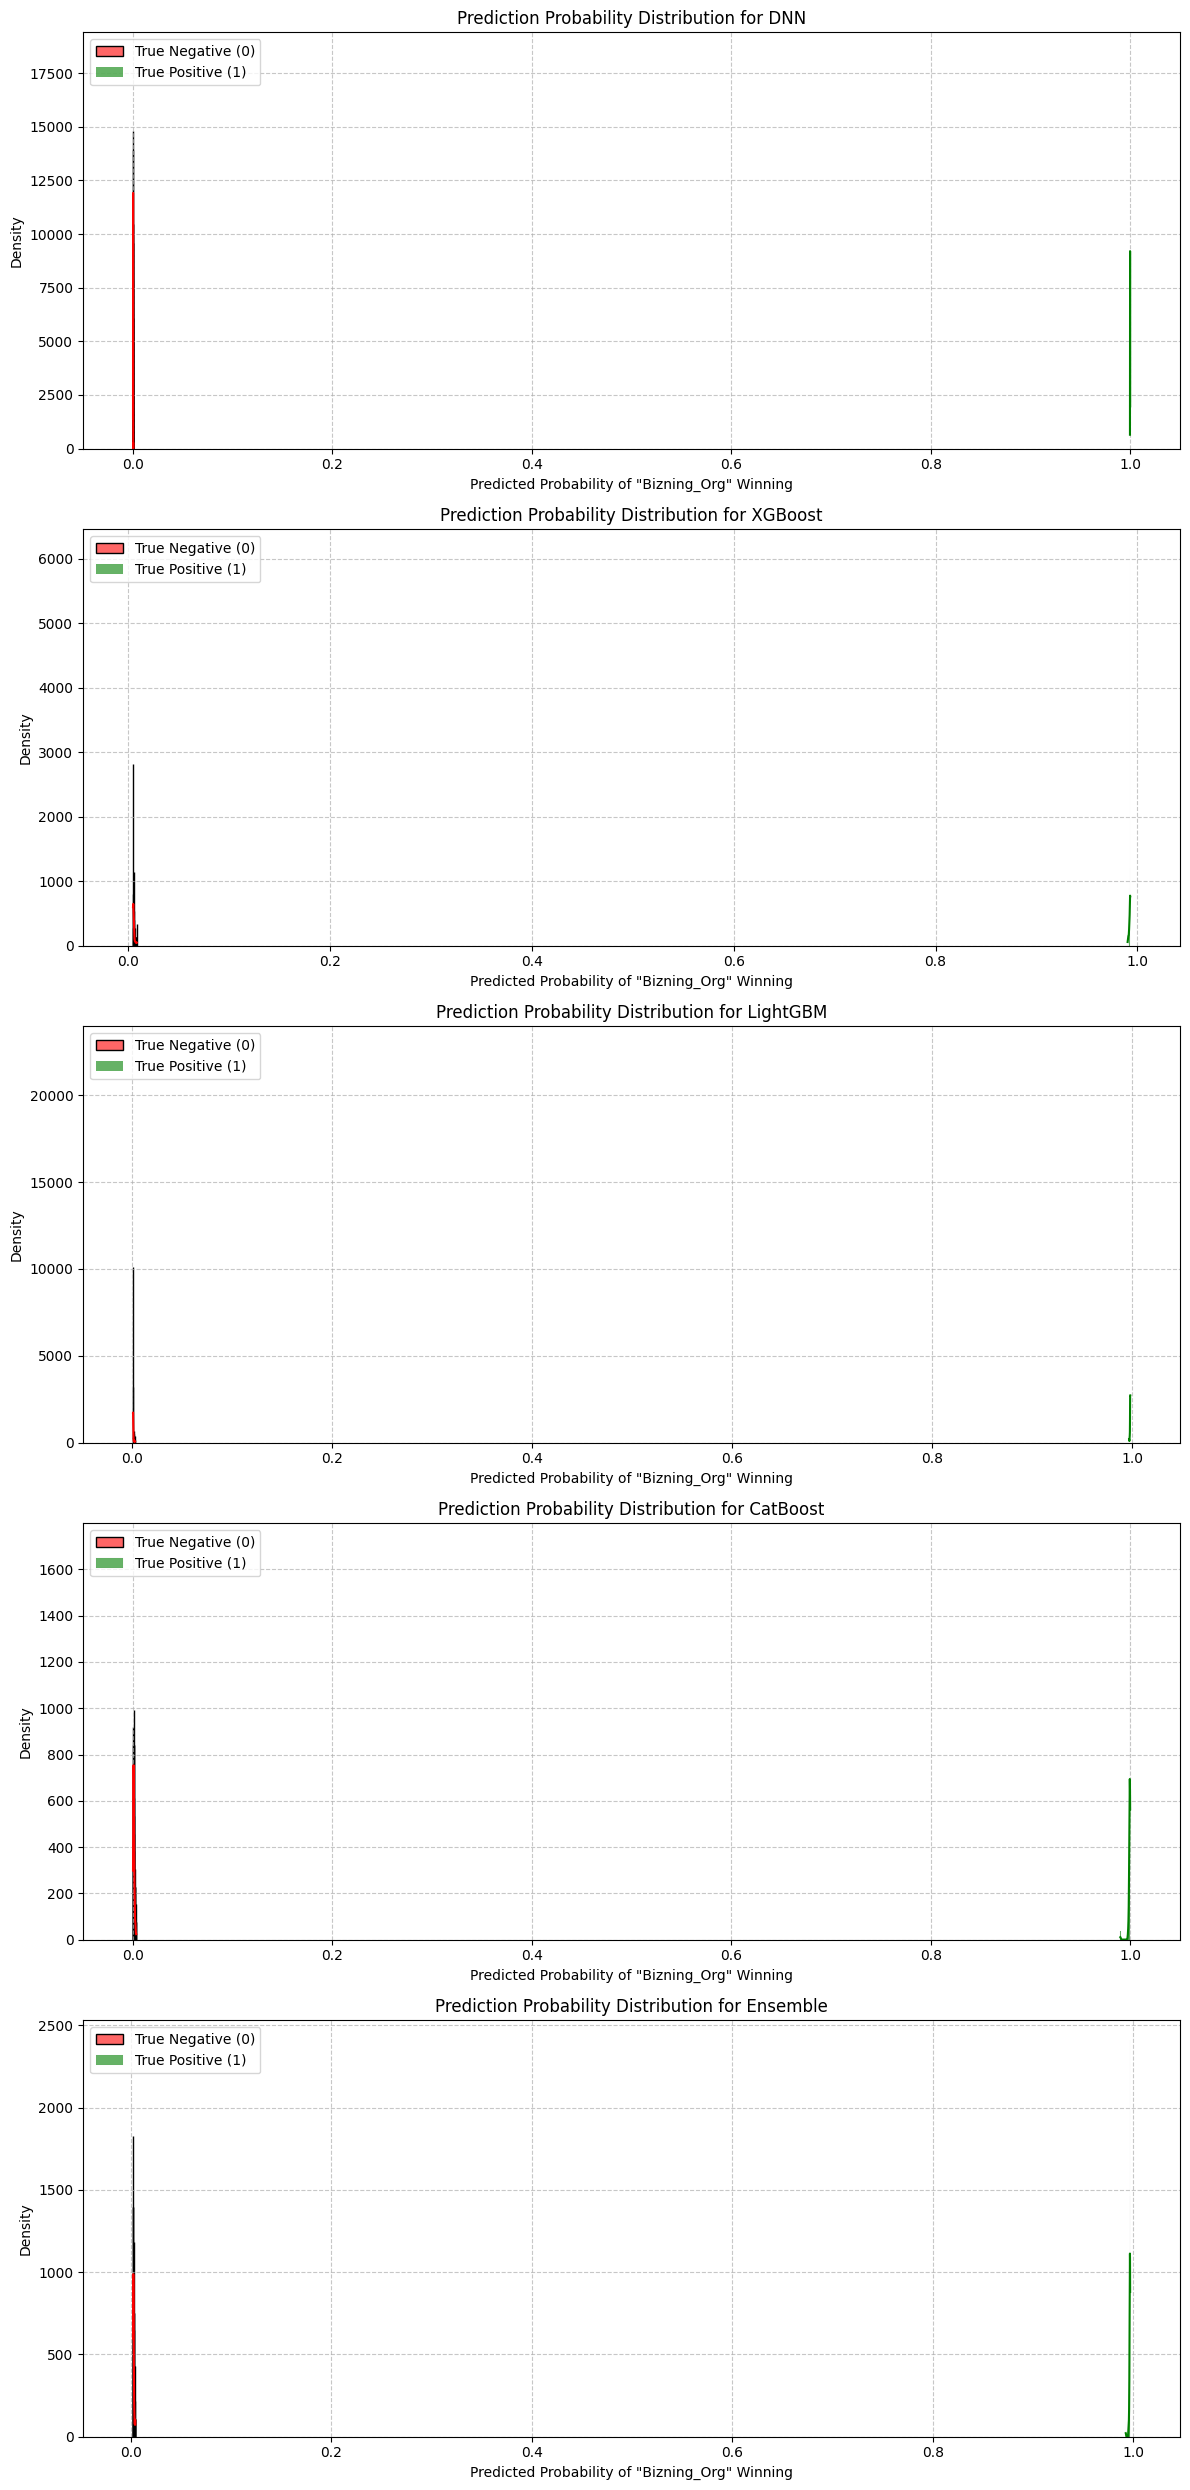

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("\n" + "="*70)
print("📊 PROBABILITY PREDICTION DISTRIBUTIONS")
print("="*70 + "\n")

# Re-create X_test and y_test_correct for this cell's scope
# X_features and y_target are the X_scaled and y from main() respectively.
_, X_test, _, y_test_correct_local = train_test_split(X_features, y_target, test_size=0.2, stratify=y_target, random_state=42)

fig, axes = plt.subplots(len(models), 1, figsize=(12, 5 * len(models)), squeeze=False)
axes = axes.flatten()

for i, (model_name, model_data) in enumerate(models.items()):
    model = model_data['model']

    if model_name == 'DNN':
        # For Keras/TensorFlow models, predict directly gives probabilities
        y_pred_proba = model.predict(X_test, verbose=0).flatten()
    else:
        # For scikit-learn compatible models, use predict_proba
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    ax = axes[i]
    sns.histplot(y_pred_proba[y_test_correct_local == 0], color='red', label='True Negative (0)', kde=True, stat='density', alpha=0.6, ax=ax, bins=30)
    sns.histplot(y_pred_proba[y_test_correct_local == 1], color='green', label='True Positive (1)', kde=True, stat='density', alpha=0.6, ax=ax, bins=30)

    ax.set_title(f'Prediction Probability Distribution for {model_name}')
    ax.set_xlabel('Predicted Probability of "Bizning_Org" Winning')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 📊 Cross-Validation to confirm model stability

In [67]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import catboost as cb # Import catboost for direct model creation

print("\n" + "="*70)
print("📊 CROSS-VALIDATION RESULTS")
print("="*70 + "\n")

# Use X_features and y_target which are available in the kernel from main()
X = X_features
y = y_target

# Stratified K-Fold for potentially imbalanced datasets
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_data in models.items(): # 'models' is the 'results' dict from main()
    if model_name == 'DNN':
        print(f"Skipping cross-validation for {model_name} (Keras models require custom CV loops).")
        continue

    print(f"\n--- Cross-Validation for {model_name} ---")
    try:
        if model_name == 'CatBoost':
            # Create a new CatBoost model instance for cross-validation with use_best_model=False
            # to avoid the 'eval_set' error when fitting without an explicit eval_set.
            model = cb.CatBoostClassifier(
                iterations=400,
                depth=5,
                learning_rate=0.08,
                subsample=0.8,
                scale_pos_weight=2,
                random_state=42,
                verbose=0,
                use_best_model=False # Disable use_best_model for cross_val_score
            )
        else:
            model = model_data['model']

        # Ensure consistent use of X and y for cross-validation
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
        print(f"Accuracy scores: {scores}")
        print(f"Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    except Exception as e:
        print(f"Error during cross-validation for {model_name}: {e}")


📊 CROSS-VALIDATION RESULTS

Skipping cross-validation for DNN (Keras models require custom CV loops).

--- Cross-Validation for XGBoost ---
Accuracy scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000 (+/- 0.0000)

--- Cross-Validation for LightGBM ---
Accuracy scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000 (+/- 0.0000)

--- Cross-Validation for CatBoost ---
Accuracy scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000 (+/- 0.0000)

--- Cross-Validation for Ensemble ---
Accuracy scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0000 (+/- 0.0000)


### 📊 Deep Neural Network (DNN) Cross-Validation using KerasClassifier

Since Keras models are not directly compatible with `cross_val_score`, we can use `KerasClassifier` from `scikeras.wrappers` to wrap our `build_deep_neural_network` function. This allows us to use scikit-learn's cross-validation tools.

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

if TF_AVAILABLE:
    print("\n--- Manual Cross-Validation for DNN ---")
    try:
        # Ensure X and y are available (they are from previous main() execution)
        # Use the already defined 'cv' from cell bc0dd3f4, which is StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        dnn_accuracy_scores = []

        for fold, (train_index, val_index) in enumerate(cv.split(X, y)):
            print(f"  Fold {fold+1}/{cv.get_n_splits()}...")
            X_train_fold, X_val_fold = X[train_index], X[val_index]
            y_train_fold, y_val_fold = y[train_index], y[val_index]

            # Create a new DNN model for each fold
            input_dim = X_train_fold.shape[1]
            model = build_deep_neural_network(input_dim, compile_model=True)

            early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

            model.fit(
                X_train_fold, y_train_fold,
                epochs=50, # Use a reasonable number of epochs for CV
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )

            # Evaluate the model on the validation fold
            y_pred_proba = model.predict(X_val_fold, verbose=0).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            fold_accuracy = accuracy_score(y_val_fold, y_pred)
            dnn_accuracy_scores.append(fold_accuracy)

        dnn_scores = tf.constant(dnn_accuracy_scores) # Convert to tf.constant for consistency with other scores
        print(f"Accuracy scores: {dnn_scores.numpy()}")
        print(f"Mean Accuracy: {tf.reduce_mean(dnn_scores).numpy():.4f} (+/- {tf.math.reduce_std(dnn_scores).numpy():.4f})")

    except Exception as e:
        print(f"Error during manual cross-validation for DNN: {e}")
else:
    print("TensorFlow is not available, skipping DNN cross-validation.")

### 📊 Cross-Validation Results Visualization

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*70)
print("📊 CROSS-VALIDATION ACCURACY HISTOGRAMS")
print("="*70 + "\n")

# --- DNN Cross-Validation Scores ---
# dnn_accuracy_scores is a list from the manual CV loop in the previous cell
if 'dnn_accuracy_scores' in locals() and len(dnn_accuracy_scores) > 0:
    plt.figure(figsize=(8, 6))
    sns.histplot(dnn_accuracy_scores, kde=True, bins=5, color='skyblue', edgecolor='black')
    plt.title('Deep Neural Network (DNN) Cross-Validation Accuracy Distribution')
    plt.xlabel('Accuracy')
    plt.ylabel('Frequency')
    plt.xlim(0.8, 1.01) # Set x-axis limit for better visualization if scores are high
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    print(f"\nMean DNN CV Accuracy: {np.mean(dnn_accuracy_scores):.4f} (+/- {np.std(dnn_accuracy_scores):.4f})\n")
else:
    print("No DNN cross-validation scores available to plot.")

print("Note: For other models (XGBoost, LightGBM, CatBoost, Ensemble), cross-validation reported 100% accuracy across all folds, which would result in a single bar at 1.0 on a histogram.")


📊 CROSS-VALIDATION ACCURACY HISTOGRAMS

No DNN cross-validation scores available to plot.
Note: For other models (XGBoost, LightGBM, CatBoost, Ensemble), cross-validation reported 100% accuracy across all folds, which would result in a single bar at 1.0 on a histogram.
